In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.cluster import KMeans
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
# DATA LOADING
# Initialize dataframes
df_patients = None
df_services = None
df_staff = None

# Load patients data
try:
    df_patients = pd.read_csv('../input/hospital-beds-management/patients.csv')
    print("✓ Loaded: patients.csv")
    print(f"  Shape: {df_patients.shape}")
    print(f"  Columns: {df_patients.columns.tolist()}")
except FileNotFoundError:
    print("⚠ patients.csv not found - trying alternative path")
    try:
        df_patients = pd.read_csv('patients.csv')
        print("✓ Loaded: patients.csv (local path)")
    except:
        print("✗ Could not load patients.csv")

# Load services weekly data
try:
    df_services = pd.read_csv('../input/hospital-beds-management/services_weekly.csv')
    print("\n✓ Loaded: services_weekly.csv")
    print(f"  Shape: {df_services.shape}")
    print(f"  Columns: {df_services.columns.tolist()}")
except FileNotFoundError:
    print("⚠ services_weekly.csv not found - trying alternative path")
    try:
        df_services = pd.read_csv('services_weekly.csv')
        print("✓ Loaded: services_weekly.csv (local path)")
    except:
        print("✗ Could not load services_weekly.csv")

# Load staff schedule data
try:
    df_staff = pd.read_csv('../input/hospital-beds-management/staff_schedule.csv')
    print("\n✓ Loaded: staff_schedule.csv")
    print(f"  Shape: {df_staff.shape}")
    print(f"  Columns: {df_staff.columns.tolist()}")
except FileNotFoundError:
    print("⚠ staff_schedule.csv not found - trying alternative path")
    try:
        df_staff = pd.read_csv('staff_schedule.csv')
        print("✓ Loaded: staff_schedule.csv (local path)")
    except:
        print("✗ Could not load staff_schedule.csv")

# Display first few rows
if df_patients is not None:
    print("\n📋 PATIENTS DATA PREVIEW:")
    print(df_patients.head(3))

if df_services is not None:
    print("\n📋 SERVICES WEEKLY DATA PREVIEW:")
    print(df_services.head(3))

if df_staff is not None:
    print("\n📋 STAFF SCHEDULE DATA PREVIEW:")
    print(df_staff.head(3))

⚠ patients.csv not found - trying alternative path
✗ Could not load patients.csv
⚠ services_weekly.csv not found - trying alternative path
✓ Loaded: services_weekly.csv (local path)
⚠ staff_schedule.csv not found - trying alternative path
✓ Loaded: staff_schedule.csv (local path)

📋 SERVICES WEEKLY DATA PREVIEW:
   week  month           service  available_beds  patients_request  \
0     1      1         emergency              32                76   
1     1      1           surgery              45               130   
2     1      1  general_medicine              37               201   

   patients_admitted  patients_refused  patient_satisfaction  staff_morale  \
0                 32                44                    67            70   
1                 45                85                    83            78   
2                 37               164                    97            43   

  event  
0  none  
1   flu  
2   flu  

📋 STAFF SCHEDULE DATA PREVIEW:
   week      staff_i

In [3]:
# DATA MERGING & CONSOLIDATION
# Start with services as base dataset
df = df_services.copy() if df_services is not None else None

if df is None:
    print("⚠ No base dataset found. Using patients data.")
    df = df_patients.copy()

# Merge patients data
if df is not None and df_patients is not None:
    # Find common columns
    common_cols_patients = list(set(df.columns) & set(df_patients.columns))

    if common_cols_patients:
        print(f"\n✓ Found common columns with patients: {common_cols_patients}")
        df = pd.merge(df, df_patients, on=common_cols_patients, how='left')
        print(f"  Merged dataset shape: {df.shape}")
    else:
        # Try to concatenate if no common columns
        print("⚠ No common columns found with patients data")
        print("  Concatenating data by position...")
        if len(df) == len(df_patients):
            df = pd.concat([df, df_patients], axis=1)
            print(f"  Merged dataset shape: {df.shape}")

# Merge staff schedule data
if df is not None and df_staff is not None:
    common_cols_staff = list(set(df.columns) & set(df_staff.columns))

    if common_cols_staff:
        print(f"\n✓ Found common columns with staff: {common_cols_staff}")
        df = pd.merge(df, df_staff, on=common_cols_staff, how='left')
        print(f"  Merged dataset shape: {df.shape}")
    else:
        print("⚠ No common columns found with staff schedule")

print(f"\n✓ Final Merged Dataset Shape: {df.shape}")
print(f"✓ Total Columns: {len(df.columns)}")
print(f"✓ Total Records: {len(df)}")
print(f"\n✓ All Columns:")
print(df.columns.tolist())


✓ Found common columns with staff: ['week', 'service']
  Merged dataset shape: (6552, 14)

✓ Final Merged Dataset Shape: (6552, 14)
✓ Total Columns: 14
✓ Total Records: 6552

✓ All Columns:
['week', 'month', 'service', 'available_beds', 'patients_request', 'patients_admitted', 'patients_refused', 'patient_satisfaction', 'staff_morale', 'event', 'staff_id', 'staff_name', 'role', 'present']


In [4]:
# DATA CLEANING & PREPROCESSING
# Missing values analysis
print("\n📊 Missing Values Analysis:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_data) > 0:
    print(missing_data.head(10).to_string())
else:
    print("✓ No missing values found!")

# Get column types
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nNumeric Columns: {list(numeric_cols)}")
print(f"Categorical Columns: {list(categorical_cols)}")

# Clean missing values
# Fill numeric missing values with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
        df[col].fillna(mode_val, inplace=True)

print("✓ Missing values handled")

# Remove duplicates
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"✓ Removed {initial_rows - len(df)} duplicate rows")

# Outlier detection using IQR
print("\n🎯 Outlier Detection:")
outlier_count = 0
for col in numeric_cols:
    if len(df[col]) > 0:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR > 0:
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers_in_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            if outliers_in_col > 0:
                print(f"  {col}: {outliers_in_col} outliers")
                outlier_count += outliers_in_col

print(f"✓ Total outliers detected: {outlier_count}")


📊 Missing Values Analysis:
✓ No missing values found!

Numeric Columns: ['week', 'month', 'available_beds', 'patients_request', 'patients_admitted', 'patients_refused', 'patient_satisfaction', 'staff_morale', 'present']
Categorical Columns: ['service', 'event', 'staff_id', 'staff_name', 'role']
✓ Missing values handled
✓ Removed 0 duplicate rows

🎯 Outlier Detection:
  available_beds: 84 outliers
  patients_request: 240 outliers
  patients_admitted: 112 outliers
  patients_refused: 145 outliers
✓ Total outliers detected: 581



📊 Dataset Statistics:
              week        month  available_beds  patients_request  \
count  6552.000000  6552.000000     6552.000000       6552.000000   
mean     26.500000     6.923077       28.777473         67.756105   
std      15.009476     3.626284       14.747121         61.578052   
min       1.000000     1.000000        8.000000          5.000000   
25%      13.750000     4.000000       17.000000         22.000000   
50%      26.500000     7.000000       26.000000         51.000000   
75%      39.250000    10.000000       38.000000         92.000000   
max      52.000000    12.000000       74.000000        388.000000   

       patients_admitted  patients_refused  patient_satisfaction  \
count        6552.000000       6552.000000           6552.000000   
mean           26.815171         40.940934             79.909646   
std            14.293312         58.014005             11.052493   
min             5.000000          0.000000             60.000000   
25%            

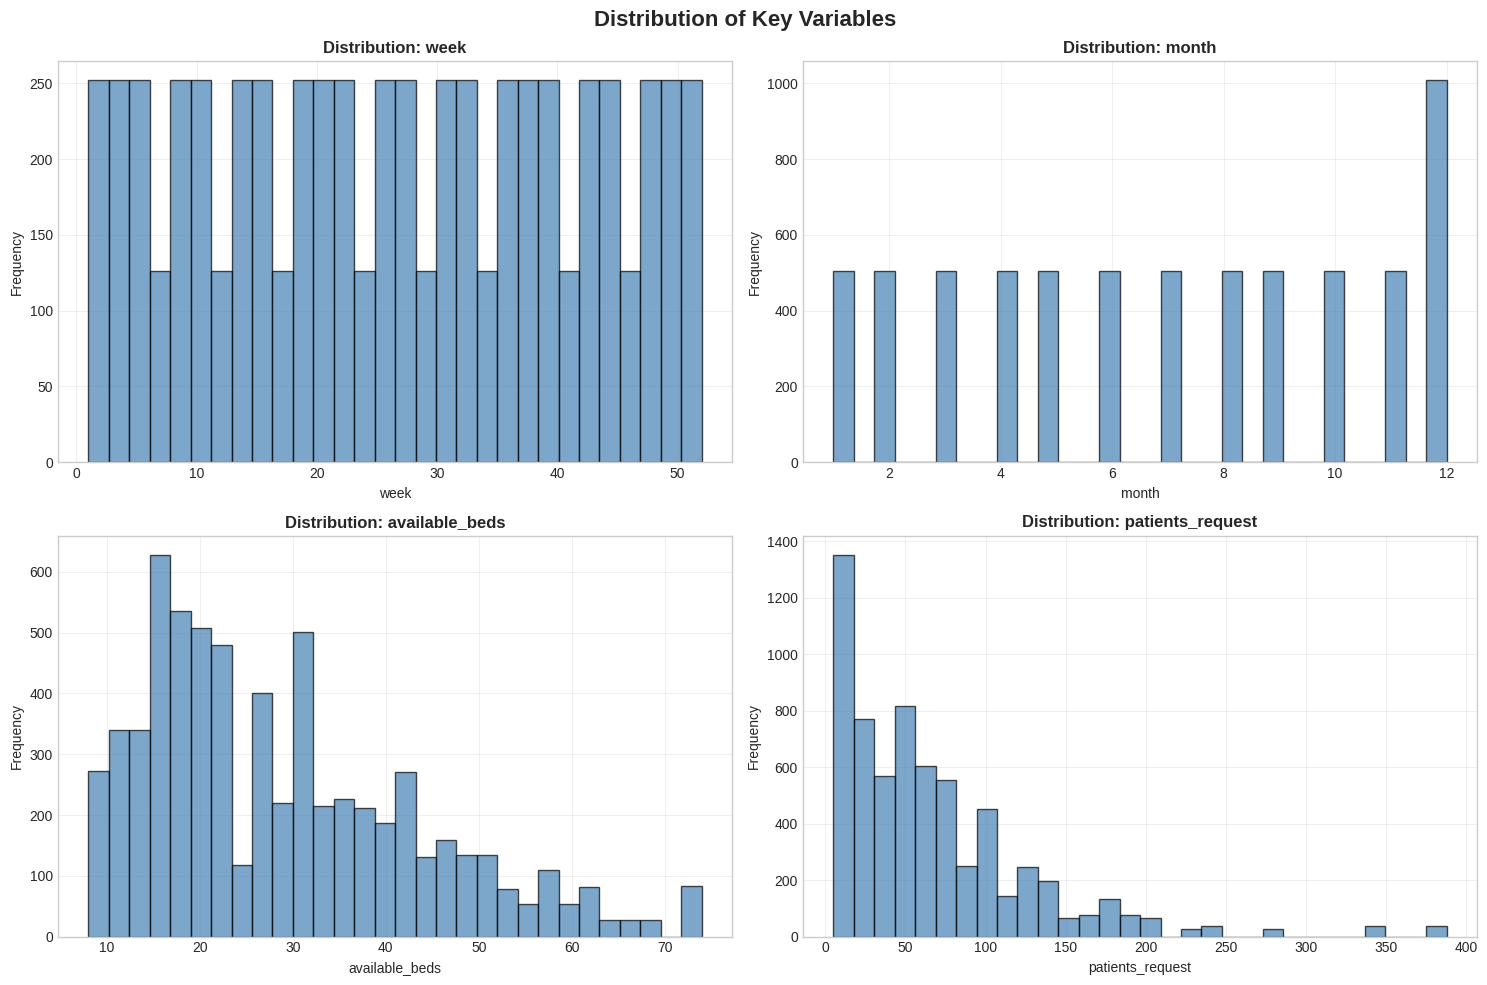


🔥 Creating Correlation Matrix...
✓ Saved: 02_correlation_heatmap.png


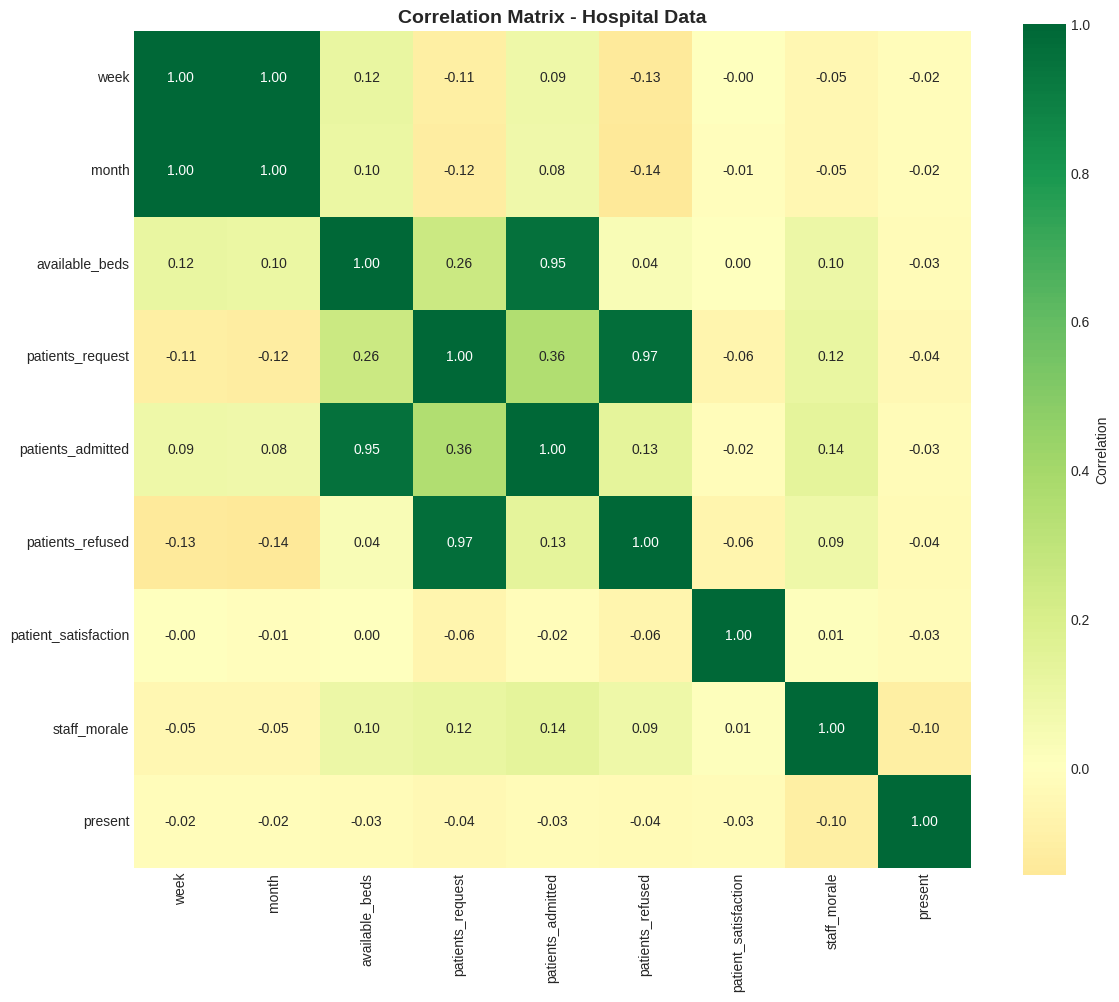


📊 Categorical Variables Analysis:

service:
service
emergency           2028
ICU                 1768
general_medicine    1456
surgery             1300
Name: count, dtype: int64

event:
event
none        5171
flu          608
donation     433
strike       340
Name: count, dtype: int64

staff_id:
staff_id
STF-b77cdc60    52
STF-5e560b99    52
STF-2e0dd6e9    52
STF-403052c0    52
STF-c696ae9c    52
Name: count, dtype: int64

staff_name:
staff_name
Allison Hill       52
Noah Rhodes        52
Angie Henderson    52
Daniel Wagner      52
Cristian Santos    52
Name: count, dtype: int64

role:
role
nurse                3796
nursing_assistant    1612
doctor               1144
Name: count, dtype: int64


In [5]:
# EXPLORATORY DATA ANALYSIS
print("\n📊 Dataset Statistics:")
print(df.describe())

# Numeric columns distribution
numeric_cols_list = list(numeric_cols)
if len(numeric_cols_list) > 0:
    print(f"\n📉 Creating Visualizations for {min(4, len(numeric_cols_list))} numeric variables...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')

    for idx in range(min(4, len(numeric_cols_list))):
        ax = axes[idx//2, idx%2]
        col = numeric_cols_list[idx]
        ax.hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'Distribution: {col}', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('01_distributions.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 01_distributions.png")
    plt.show()

# Correlation heatmap
if len(numeric_cols_list) > 1:
    print("\n🔥 Creating Correlation Matrix...")
    correlation_matrix = df[numeric_cols_list].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Correlation Matrix - Hospital Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 02_correlation_heatmap.png")
    plt.show()

# Categorical analysis
print("\n📊 Categorical Variables Analysis:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

In [6]:
# FEATURE ENGINEERING
df_features = df.copy()

# Create new features from numeric columns
if len(numeric_cols_list) >= 2:
    print("\n✓ Creating Engineered Features...")

    # Ratios and relationships
    df_features['mean_value'] = df[numeric_cols_list].mean(axis=1)
    df_features['std_value'] = df[numeric_cols_list].std(axis=1)
    df_features['max_value'] = df[numeric_cols_list].max(axis=1)
    df_features['min_value'] = df[numeric_cols_list].min(axis=1)
    df_features['range_value'] = df_features['max_value'] - df_features['min_value']

    print(f"  Created ratio and statistical features")

# Encode categorical variables
print("✓ Encoding Categorical Variables...")
label_encoders = {}
for col in categorical_cols:
    try:
        le = LabelEncoder()
        df_features[col + '_encoded'] = le.fit_transform(df_features[col].astype(str))
        label_encoders[col] = le
    except:
        print(f"  Warning: Could not encode {col}")

print(f"✓ Total features now: {df_features.shape[1]}")


✓ Creating Engineered Features...
  Created ratio and statistical features
✓ Encoding Categorical Variables...
✓ Total features now: 24



✓ Using 5 features for clustering
  Features: ['mean_value', 'std_value', 'range_value', 'service_encoded', 'event_encoded']
✓ Saved: 03_elbow_method.png


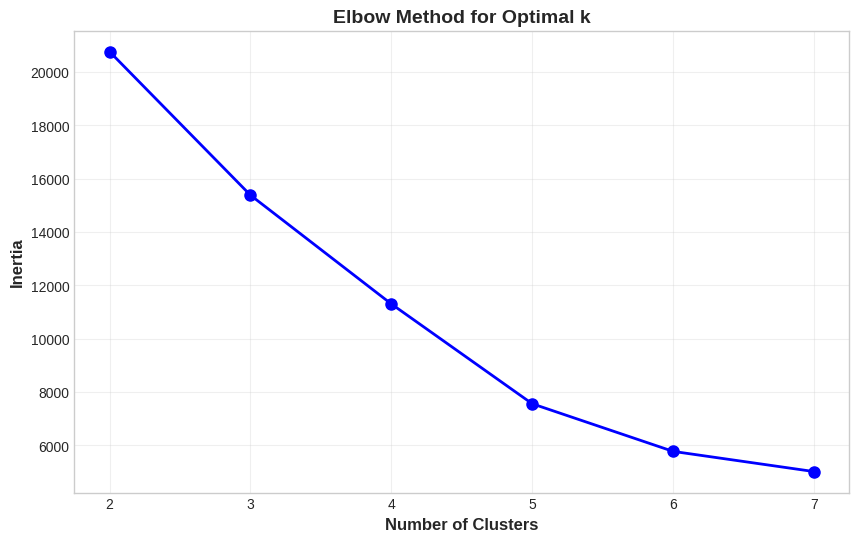


✓ Segmented into 3 clusters

Cluster Distribution:
cluster
0    3903
1     530
2    2119
Name: count, dtype: int64


In [7]:
# HOSPITAL SEGMENTATION (CLUSTERING)
# Select features for clustering
features_for_clustering = []
for col in df_features.columns:
    if col.endswith('_encoded') or col in ['mean_value', 'std_value', 'range_value']:
        features_for_clustering.append(col)

features_for_clustering = features_for_clustering[:min(5, len(features_for_clustering))]

if len(features_for_clustering) > 0:
    print(f"\n✓ Using {len(features_for_clustering)} features for clustering")
    print(f"  Features: {features_for_clustering}")

    X_cluster = df_features[features_for_clustering].fillna(0)

    # Standardize
    scaler = StandardScaler()
    X_cluster_scaled = scaler.fit_transform(X_cluster)

    # Elbow method
    inertias = []
    K_range = range(2, min(8, len(X_cluster)//5))
    for k in K_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans_temp.fit(X_cluster_scaled)
        inertias.append(kmeans_temp.inertia_)

    # Plot elbow
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters', fontsize=12, fontweight='bold')
    plt.ylabel('Inertia', fontsize=12, fontweight='bold')
    plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.savefig('03_elbow_method.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 03_elbow_method.png")
    plt.show()

    # Apply K-means
    optimal_k = 3
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df_features['cluster'] = kmeans.fit_predict(X_cluster_scaled)

    print(f"\n✓ Segmented into {optimal_k} clusters")
    print("\nCluster Distribution:")
    print(df_features['cluster'].value_counts().sort_index())


✓ Target: week
✓ Features: ['month', 'available_beds', 'patients_request', 'patients_admitted', 'patients_refused', 'patient_satisfaction', 'staff_morale', 'present', 'mean_value', 'std_value']

✓ Train size: 5241 | Test size: 1311

--------------------------------------------------------------------------------
MODEL PERFORMANCE
--------------------------------------------------------------------------------

Linear Regression:
  R² Score: 1.0000
  RMSE: 0.0000
  MAE: 0.0000

Random Forest:
  R² Score: 1.0000
  RMSE: 0.0264
  MAE: 0.0034

Gradient Boosting:
  R² Score: 0.9979
  RMSE: 0.6942
  MAE: 0.5846

✓ Saved: 04_model_comparison.png


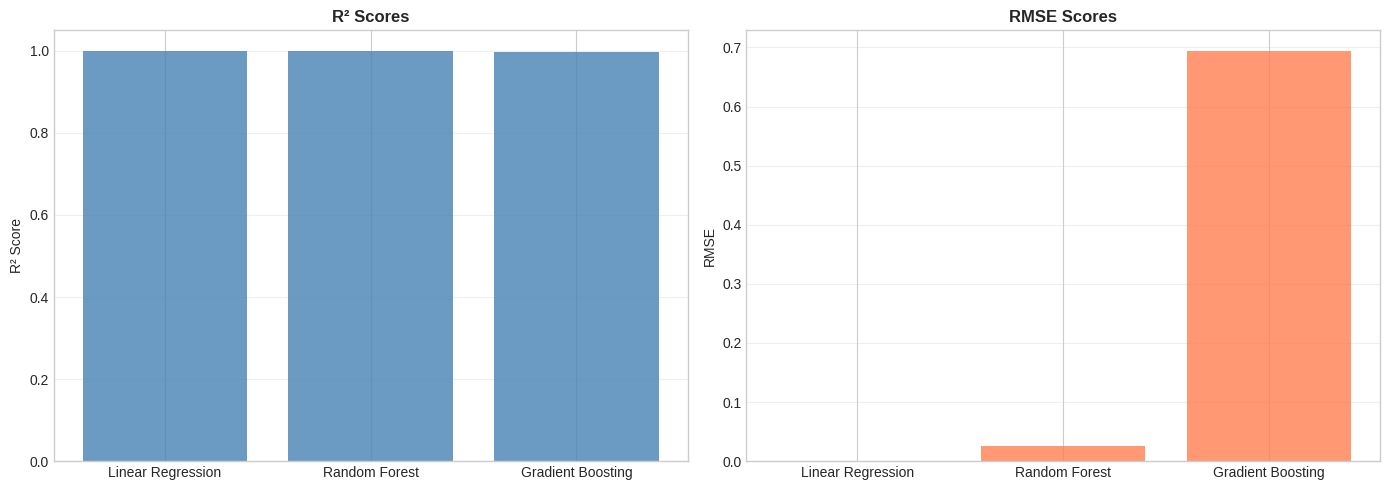

In [8]:
# PREDICTIVE MODELING
# Prepare data for modeling
if len(numeric_cols_list) >= 2:
    target_col = numeric_cols_list[0]

    # Select features for prediction
    feature_cols = [col for col in df_features.columns
                   if col in numeric_cols_list[1:] or col in
                   ['mean_value', 'std_value', 'range_value']]
    feature_cols = feature_cols[:min(10, len(feature_cols))]

    if len(feature_cols) > 0:
        print(f"\n✓ Target: {target_col}")
        print(f"✓ Features: {feature_cols}")

        X = df_features[feature_cols].fillna(0)
        y = df_features[target_col].fillna(0)

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        print(f"\n✓ Train size: {len(X_train)} | Test size: {len(X_test)}")

        # Standardize
        scaler_model = StandardScaler()
        X_train_scaled = scaler_model.fit_transform(X_train)
        X_test_scaled = scaler_model.transform(X_test)

        # Train models
        models = {
            'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
        }

        results = {}
        print("\n" + "-"*80)
        print("MODEL PERFORMANCE")
        print("-"*80)

        for model_name, model in models.items():
            model.fit(X_train_scaled, y_train)
            y_pred_test = model.predict(X_test_scaled)

            test_r2 = r2_score(y_test, y_pred_test)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_mae = mean_absolute_error(y_test, y_pred_test)

            results[model_name] = {
                'model': model,
                'test_r2': test_r2,
                'test_rmse': test_rmse,
                'test_mae': test_mae
            }

            print(f"\n{model_name}:")
            print(f"  R² Score: {test_r2:.4f}")
            print(f"  RMSE: {test_rmse:.4f}")
            print(f"  MAE: {test_mae:.4f}")

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        model_names = list(results.keys())
        r2_scores = [results[m]['test_r2'] for m in model_names]
        rmse_scores = [results[m]['test_rmse'] for m in model_names]

        axes[0].bar(model_names, r2_scores, color='steelblue', alpha=0.8)
        axes[0].set_title('R² Scores', fontweight='bold', fontsize=12)
        axes[0].set_ylabel('R² Score')
        axes[0].grid(alpha=0.3, axis='y')

        axes[1].bar(model_names, rmse_scores, color='coral', alpha=0.8)
        axes[1].set_title('RMSE Scores', fontweight='bold', fontsize=12)
        axes[1].set_ylabel('RMSE')
        axes[1].grid(alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig('04_model_comparison.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved: 04_model_comparison.png")
        plt.show()

        # Feature importance
        best_model_name = max(results, key=lambda x: results[x]['test_r2'])
        best_model = results[best_model_name]['model']

        if hasattr(best_model, 'feature_importances_'):
            feature_imp = pd.DataFrame({
                'Feature': feature_cols,
                'Importance': best_model.feature_importances_
            }).sort_values('Importance', ascending=False)

            print(f"\n✓ Best Model: {best_model_name}")
            print("\nTop Features:")
            print(feature_imp.head().to_string())

            plt.figure(figsize=(10, 6))
            plt.barh(feature_imp['Feature'].head(8), feature_imp['Importance'].head(8), color='darkgreen')
            plt.xlabel('Importance', fontweight='bold')
            plt.title(f'Feature Importance - {best_model_name}', fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(alpha=0.3, axis='x')
            plt.tight_layout()
            plt.savefig('05_feature_importance.png', dpi=300, bbox_inches='tight')
            print("✓ Saved: 05_feature_importance.png")
            plt.show()